In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import folium
from folium.plugins import HeatMap


In [13]:
data = pd.read_csv("USA_ACCIDENTS.csv")

print("Shape:", data.shape)
data.head()

Shape: (2005933, 8)


,Unnamed: 0,ID,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F)
0,0,A-1,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9
1,1,A-2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9
2,2,A-3,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0
3,3,A-4,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1
4,4,A-5,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0


In [14]:
data = data[['Start_Lat', 'Start_Lng']]
data.head()

,Start_Lat,Start_Lng
0,39.865147,-84.058723
1,39.928059,-82.831184
2,39.063148,-84.032608
3,39.747753,-84.205582
4,39.627781,-84.188354


In [15]:
# Remove missing values
data = data.dropna()

# Remove duplicates
data = data.drop_duplicates()

print("Cleaned Shape:", data.shape)

Cleaned Shape: (802944, 2)


In [16]:
data = data.sample(n=30000, random_state=42)

In [17]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

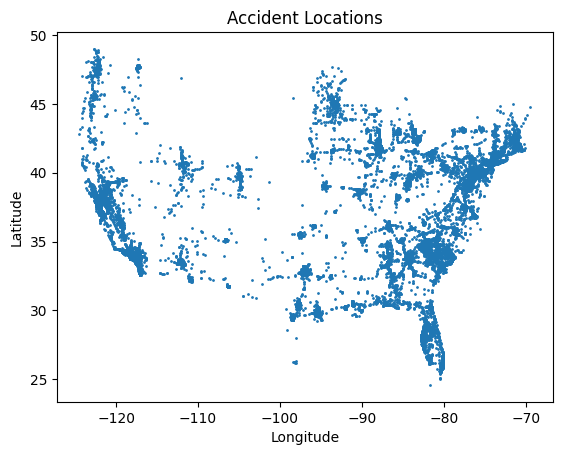

In [18]:
plt.scatter(data['Start_Lng'], data['Start_Lat'], s=1)
plt.title("Accident Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Scatter Plot Observations

From the initial scatter plot, it is evident that accident data is densely concentrated along coastal regions, particularly on the East and West Coasts of the USA, and in major urban areas. Conversely, central regions of the US show a significantly lower density of recorded accidents.

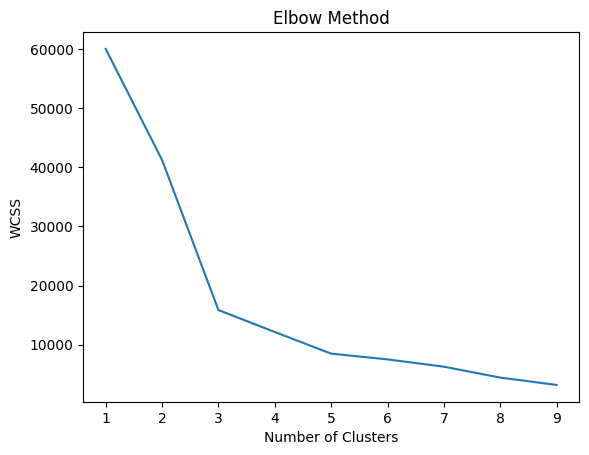

In [19]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Elbow Method Results

The Elbow Method plot shows the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters. The 'elbow' point, where the rate of decrease in WCSS significantly slows down, was observed at `K = 5`. This indicates that `5` is an optimal number of clusters for this dataset, balancing model complexity with explained variance.

In [47]:
import numpy as np
from scipy.spatial import distance # Moved import here to keep all imports together at the top of the notebook for consistency.

k = 5  # choose based on elbow

kmeans = KMeans(n_clusters=k, random_state=42)
data['cluster'] = kmeans.fit_predict(scaled_data)

centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

# Snap to nearest real accident point
real_centers = []

for center in centers_original:
    closest_point = data.loc[
        ((data[['Start_Lat','Start_Lng']] - center)**2).sum(axis=1).idxmin()
    ]
    real_centers.append([closest_point['Start_Lat'], closest_point['Start_Lng']])

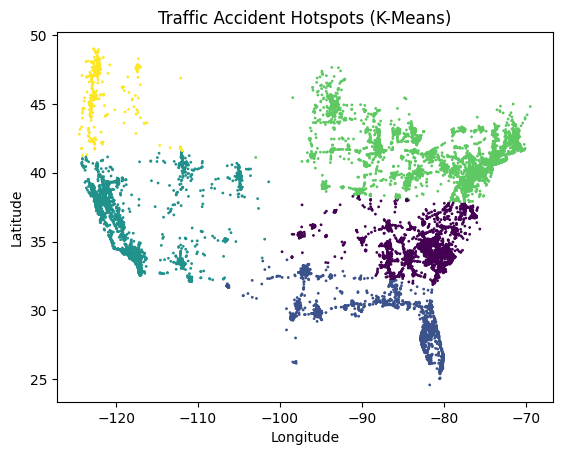

In [21]:
plt.scatter(data['Start_Lng'], data['Start_Lat'],
            c=data['cluster'], cmap='viridis', s=1)

plt.title("Traffic Accident Hotspots (K-Means)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

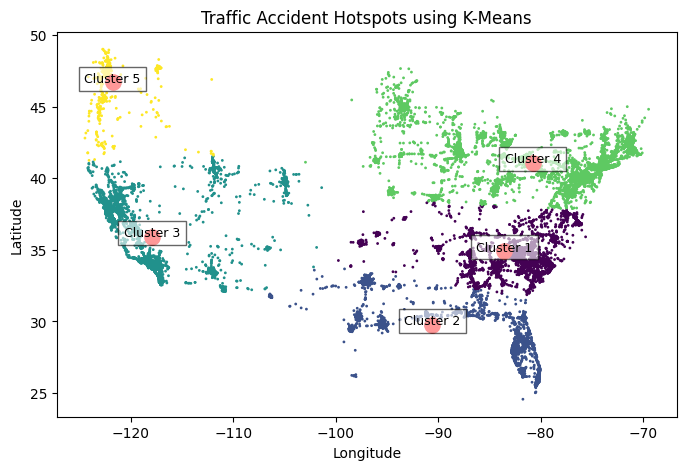

In [65]:
plt.figure(figsize=(8,5))

# Scatter plot
scatter = plt.scatter(data['Start_Lng'], data['Start_Lat'],
                      c=data['cluster'], cmap='viridis', s=1)

# Get cluster centers
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centroids
plt.scatter(centers_original[:,1], centers_original[:,0],
            color='red', s=120)

# Add labels for each cluster at centroid
for i, (lat, lng) in enumerate(centers_original):
    plt.text(lng, lat,
             f'Cluster {i+1}',
             fontsize=9,
             color='black',
             ha='center',
             bbox=dict(facecolor='white', alpha=0.6))

# Title & labels
plt.title("Traffic Accident Hotspots using K-Means")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


### Hotspot Logic Explanation

When observing the red markers (representing K-Means cluster centers) on the accident location plots or heatmaps, it's important to understand how K-Means works. K-Means identifies the geometric center (mean) of all data points within a cluster. Therefore, these markers represent the average location of accidents within their respective clusters, not necessarily the absolute highest density point or 'peak' of a visual hotspot on a heatmap. This is why some red markers might not appear directly on the most visually dense areas, as heatmaps often smooth the density across a region, while K-Means focuses on the centroid of the cluster's data points.

In [29]:
score = silhouette_score(scaled_data, data['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.5304778210025644


In [3]:
import pandas as pd

# Reload data to ensure 'data' DataFrame is available
data = pd.read_csv("USA_ACCIDENTS.csv")


In [4]:
data = data[['Start_Lat', 'Start_Lng']]


In [5]:
# Remove missing values
data = data.dropna()

# Remove duplicates
data = data.drop_duplicates()

print("Cleaned Shape:", data.shape)


Cleaned Shape: (645984, 2)


In [6]:
data = data.sample(n=30000, random_state=42)


### Model Evaluation: Silhouette Score

A Silhouette Score of approximately `0.53` was calculated for the K-Means clustering with 5 clusters. A Silhouette Score ranges from -1 to 1, where:
-   Values near +1 indicate that the sample is far away from the neighboring clusters.
-   Values near 0 indicate that the sample is on or very close to the decision boundary between two neighboring clusters.
-   Negative values indicate that those samples might have been assigned to the wrong cluster.

Our score of `0.53` suggests a moderate degree of cluster separation, indicating a reasonable grouping of accident hotspots. The clusters are distinguishable, though there might be some overlap or samples that are not perfectly distinct.

In [7]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[data['Start_Lat'].mean(), data['Start_Lng'].mean()],
    zoom_start=5,
    tiles='cartodbpositron'   # cleaner background
)

heat_data = data[['Start_Lat', 'Start_Lng']].values.tolist()

HeatMap(
    heat_data,
    radius=6,
    blur=5,
    min_opacity=0.2,
    max_zoom=10,
    gradient={
        0.2: 'blue',
        0.4: 'green',
        0.6: 'yellow',
        0.8: 'orange',
        1.0: 'red'
    }
).add_to(m)

m   # 👈 display at the END

### Results Discussion

The analysis of traffic accident data using K-Means clustering and a Folium heatmap reveals distinct patterns in accident distribution across the USA:

**High Accident Density Areas:**
*   **East Coast:** Several significant hotspots are identified along the East Coast, suggesting high traffic volume and incident rates in major metropolitan areas like New York, Philadelphia, and cities in Florida and the Carolinas.
*   **California:** The West Coast, particularly California, shows high accident density, concentrated around large urban centers such as Los Angeles and the Bay Area, and along major interstate corridors.
*   **Urban Regions:** Generally, urban and densely populated areas exhibit a higher concentration of accidents, which is expected due to increased vehicle miles traveled and more complex traffic environments.

**Low Accident Density Areas:**
*   **Rural/Central US:** Conversely, vast rural regions and the central parts of the United States show significantly lower accident densities. This is primarily attributed to sparser populations and less traffic.

In [8]:
m.save("accident_New_hotspots.html")

In [9]:
from google.colab import files
files.download("accident_New_hotspots.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### What this gives you (Hotspots changing over time)

By running K-Means clustering for each month, we can identify accident hotspots that are specific to certain times of the year. This approach helps in understanding temporal patterns in accident occurrences. For example:

*   **Hotspots in January:** Might reveal areas with high accident rates due to winter weather conditions.
*   **Hotspots in July:** Could indicate areas with increased accidents during summer travel periods.

This 'moving window' (simplified by month) allows for a dynamic view of accident concentrations, which can be crucial for targeted safety interventions and resource allocation based on seasonal risks.

### Step 1 & 2: Keep time column, remove missing values, convert time to datetime and sample data

In [57]:
data_time = pd.read_csv("USA_ACCIDENTS.csv")
data_time = data_time[['Start_Lat', 'Start_Lng', 'Start_Time']]
data_time = data_time.dropna()
data_time = data_time.drop_duplicates()

# Sample the data to manage computation time, similar to the main analysis
data_time = data_time.sample(n=30000, random_state=42)

data_time['Start_Time'] = pd.to_datetime(data_time['Start_Time'], format='mixed', errors='coerce')

print("Shape of data_time:", data_time.shape)
data_time.head()

Shape of data_time: (30000, 3)


,Start_Lat,Start_Lng,Start_Time
7304181,44.893200,-93.034240,2019-10-24 12:51:00
5779891,40.076925,-74.944831,2021-11-18 07:15:30
336040,47.528282,-122.360474,2017-02-08 10:55:44
3366446,31.781023,-106.420494,2017-08-14 11:35:46
5643542,41.064489,-77.603937,2021-08-15 08:34:00


### Outlier Detection and Visualization

We will perform outlier detection on the `Start_Lat` and `Start_Lng` columns of our sampled data using two common methods: Z-score and Interquartile Range (IQR). After detection, we will visualize the distributions and identified outliers using box plots.

In [54]:
# Z-score Outlier Detection
from scipy.stats import zscore

# Calculate Z-scores for 'Start_Lat' and 'Start_Lng'
data['Z_score_Lat'] = np.abs(zscore(data['Start_Lat']))
data['Z_score_Lng'] = np.abs(zscore(data['Start_Lng']))

# Define a threshold for outliers (e.g., Z-score > 3)
threshold_zscore = 3
outliers_zscore_lat = data[data['Z_score_Lat'] > threshold_zscore]
outliers_zscore_lng = data[data['Z_score_Lng'] > threshold_zscore]

print(f"Z-score outliers in Start_Lat (threshold > {threshold_zscore}): {len(outliers_zscore_lat)}")
print(f"Z-score outliers in Start_Lng (threshold > {threshold_zscore}): {len(outliers_zscore_lng)}")

display(outliers_zscore_lat.head())
display(outliers_zscore_lng.head())

Z-score outliers in Start_Lat (threshold > 3): 0
Z-score outliers in Start_Lng (threshold > 3): 0


,Start_Lat,Start_Lng,cluster,Z_score_Lat,Z_score_Lng


,Start_Lat,Start_Lng,cluster,Z_score_Lat,Z_score_Lng


In [55]:
# IQR Outlier Detection

def detect_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect IQR outliers for 'Start_Lat'
outliers_iqr_lat, lower_bound_lat, upper_bound_lat = detect_iqr_outliers(data, 'Start_Lat')
print(f"IQR outliers in Start_Lat: {len(outliers_iqr_lat)}")
print(f"  Lower Bound (Lat): {lower_bound_lat:.2f}, Upper Bound (Lat): {upper_bound_lat:.2f}")

# Detect IQR outliers for 'Start_Lng'
outliers_iqr_lng, lower_bound_lng, upper_bound_lng = detect_iqr_outliers(data, 'Start_Lng')
print(f"IQR outliers in Start_Lng: {len(outliers_iqr_lng)}")
print(f"  Lower Bound (Lng): {lower_bound_lng:.2f}, Upper Bound (Lng): {upper_bound_lng:.2f}")

display(outliers_iqr_lat.head())
display(outliers_iqr_lng.head())

IQR outliers in Start_Lat: 0
  Lower Bound (Lat): 22.62, Upper Bound (Lat): 50.61
IQR outliers in Start_Lng: 0
  Lower Bound (Lng): -156.21, Upper Bound (Lng): -35.55


,Start_Lat,Start_Lng,cluster,Z_score_Lat,Z_score_Lng


,Start_Lat,Start_Lng,cluster,Z_score_Lat,Z_score_Lng


### Box Plots for Outlier Visualization

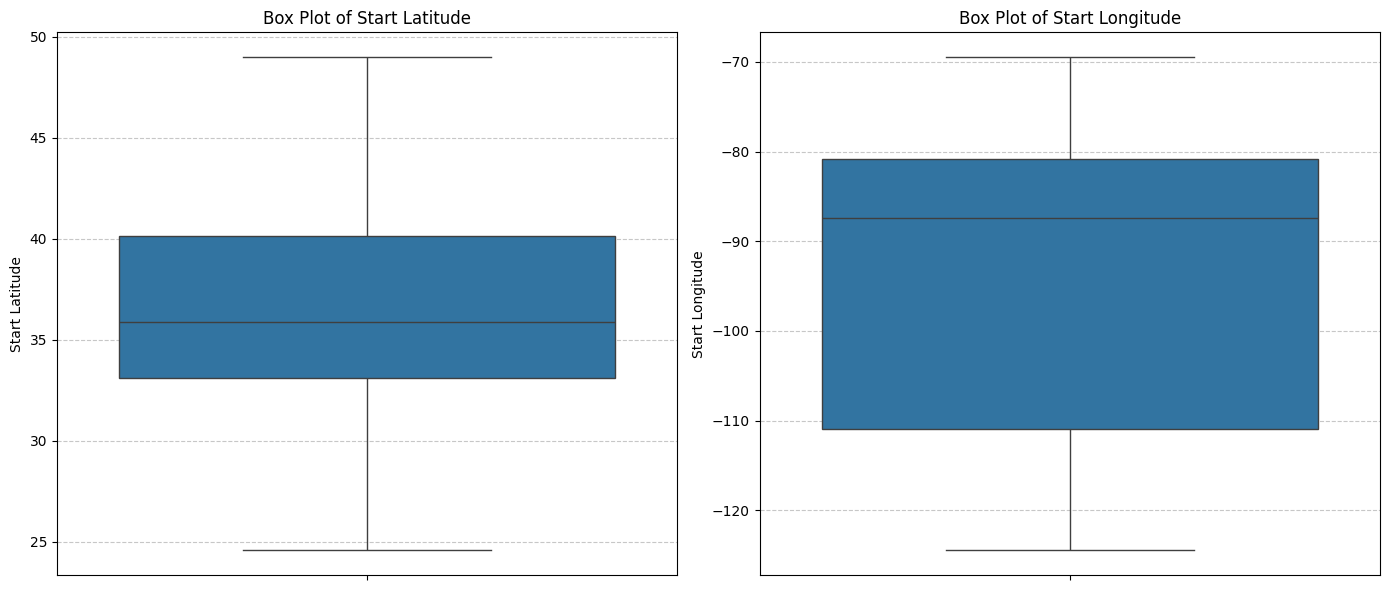

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Box plot for Start_Lat
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=data['Start_Lat'])
plt.title('Box Plot of Start Latitude')
plt.ylabel('Start Latitude')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Box plot for Start_Lng
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=data['Start_Lng'])
plt.title('Box Plot of Start Longitude')
plt.ylabel('Start Longitude')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()